In [1]:
import pandas as pd

df = pd.read_json("metrics.json", lines=True)
df

,type,data,metric
0,Metric,"{'name': 'http_reqs', 'type': 'counter', 'cont...",http_reqs
1,Point,"{'time': '2026-03-30T09:34:10.2627276+02:00', ...",http_reqs
2,Metric,"{'name': 'http_req_duration', 'type': 'trend',...",http_req_duration
3,Point,"{'time': '2026-03-30T09:34:10.2627276+02:00', ...",http_req_duration
4,Metric,"{'name': 'http_req_blocked', 'type': 'trend', ...",http_req_blocked
...,...,...,...
61,Point,"{'time': '2026-03-30T09:34:11.1869029+02:00', ...",checks
62,Point,"{'time': '2026-03-30T09:34:11.1869029+02:00', ...",data_sent
63,Point,"{'time': '2026-03-30T09:34:11.1869029+02:00', ...",data_received
64,Point,"{'time': '2026-03-30T09:34:11.1869029+02:00', ...",iteration_duration


In [2]:
df.columns

Index(['type', 'data', 'metric'], dtype='object')

In [3]:
points = df[df["type"] == "Point"].copy()


In [4]:
import pandas as pd

expanded = pd.json_normalize(points["data"])

In [5]:
expanded["metric"] = points["metric"].values


In [6]:
expanded


,time,value,tags.expected_response,tags.group,tags.method,tags.name,tags.proto,tags.scenario,tags.status,tags.url,tags.check,metric
0,2026-03-30T09:34:10.2627276+02:00,1.0000,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_reqs
1,2026-03-30T09:34:10.2627276+02:00,787.2325,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_duration
2,2026-03-30T09:34:10.2627276+02:00,3.4140,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_blocked
3,2026-03-30T09:34:10.2627276+02:00,0.9997,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_connecting
4,2026-03-30T09:34:10.2627276+02:00,0.0000,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_tls_handshaking
5,2026-03-30T09:34:10.2627276+02:00,0.0000,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_sending
6,2026-03-30T09:34:10.2627276+02:00,783.3115,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_waiting
7,2026-03-30T09:34:10.2627276+02:00,3.9210,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_receiving
8,2026-03-30T09:34:10.2627276+02:00,0.0000,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_failed
9,2026-03-30T09:34:10.2664473+02:00,1.0000,NaN,,NaN,NaN,NaN,default,NaN,NaN,signup 201,checks


In [7]:
http_df = expanded[expanded["metric"] == "http_req_duration"].copy()

In [8]:
http_df

,time,value,tags.expected_response,tags.group,tags.method,tags.name,tags.proto,tags.scenario,tags.status,tags.url,tags.check,metric
1,2026-03-30T09:34:10.2627276+02:00,787.2325,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_duration
13,2026-03-30T09:34:10.8197888+02:00,552.8110,true,,POST,storage_post_file,HTTP/1.1,smoke,201,storage_post_file,NaN,http_req_duration
27,2026-03-30T09:34:11.1116865+02:00,290.8510,true,,POST,auth_signup,HTTP/1.1,smoke,201,auth_signup,NaN,http_req_duration
37,2026-03-30T09:34:11.1869029+02:00,74.5300,true,,POST,storage_post_file,HTTP/1.1,smoke,201,storage_post_file,NaN,http_req_duration


In [9]:
http_df = http_df.dropna(axis=1, how="all").copy()

In [10]:
http_df["time"] = pd.to_datetime(http_df["time"])
http_df = http_df.sort_values("time")

# Convert to seconds relative to first timestamp
http_df["time_sec"] = (http_df["time"] - http_df["time"].min()).dt.total_seconds()

In [11]:
http_df["time"]

1    2026-03-30 09:34:10.262727600+02:00
13   2026-03-30 09:34:10.819788800+02:00
27   2026-03-30 09:34:11.111686500+02:00
37   2026-03-30 09:34:11.186902900+02:00
Name: time, dtype: datetime64[ns, UTC+02:00]

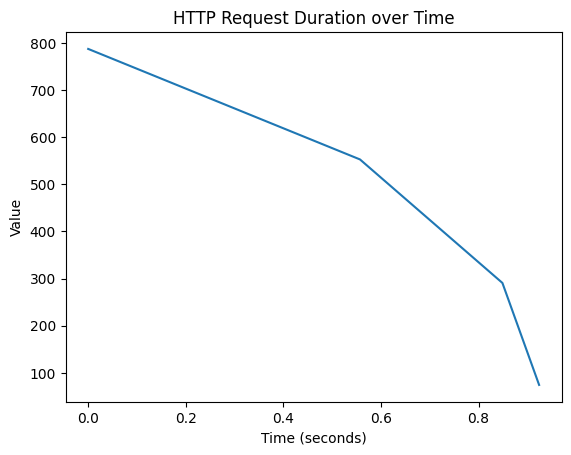

In [12]:
import matplotlib.pyplot as plt

plt.plot(http_df["time_sec"], http_df["value"])
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration over Time")
plt.show()

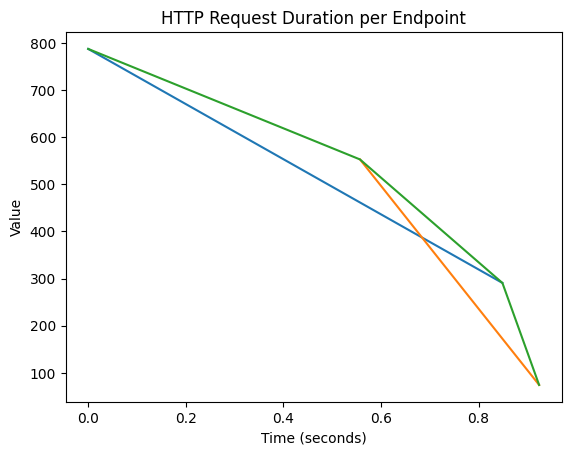

In [13]:
for name, group in http_df.groupby("tags.name"):
    group.set_index("time_sec")["value"].plot(label=name)

plt.plot(http_df["time_sec"], http_df["value"])
plt.xlabel("Time (seconds)")
plt.ylabel("Value")
plt.title("HTTP Request Duration per Endpoint")
plt.show()